# Финальный проект Python: анализ продаж и температуры

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import csv
import re

plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
!pip install xlrd

## 1. Загрузка и подготовка данных продаж

In [3]:
sales_path = Path('data.csv')
if not sales_path.exists():
    raise FileNotFoundError('Файл data.csv не найден в текущей папке.')

df = pd.read_csv(sales_path)

print('Размер исходного датасета:', df.shape)
print('Исходные колонки:')
print(list(df.columns))
df.head()

Размер исходного датасета: (301355, 5)
Исходные колонки:
['Дата', 'Склад', 'Контрагент', 'Номенклатура', 'Количество']


,Дата,Склад,Контрагент,Номенклатура,Количество
0,2018-01-04,1,address_0,product_0,4
1,2018-01-04,1,address_0,product_1,4
2,2018-01-04,1,address_0,product_2,5
3,2018-01-04,1,address_0,product_3,10
4,2018-01-04,1,address_0,product_4,2


## 2. Автоматическое определение нужных колонок

In [4]:
# Приведем названия колонок к строковому виду
df.columns = [str(c).strip() for c in df.columns]

def find_col(columns, variants):
    lower_map = {c.lower(): c for c in columns}
    for variant in variants:
        if variant.lower() in lower_map:
            return lower_map[variant.lower()]
    for c in columns:
        c_low = c.lower()
        if any(v.lower() in c_low for v in variants):
            return c
    return None

date_col = find_col(df.columns, ['Дата', 'Date'])
number_col = find_col(df.columns, ['Количество', 'Number', 'Qty', 'quantity'])
store_col = find_col(df.columns, ['Склад', 'Store'])
product_col = find_col(df.columns, ['Номенклатура', 'Product', 'Товар'])

print('Определенные колонки:')
print('date_col   =', date_col)
print('number_col =', number_col)
print('store_col  =', store_col)
print('product_col=', product_col)

if date_col is None or number_col is None:
    raise ValueError('Не удалось определить столбцы даты и количества в data.csv.')

Определенные колонки:
date_col   = Дата
number_col = Количество
store_col  = Склад
product_col= Номенклатура


## 3. Приведение данных продаж к стандартному виду

In [5]:
sales = df.copy()

rename_map = {
    date_col: 'Date',
    number_col: 'Number'
}

if store_col is not None:
    rename_map[store_col] = 'Store'
if product_col is not None:
    rename_map[product_col] = 'Product'

sales = sales.rename(columns=rename_map)

sales['Date'] = pd.to_datetime(sales['Date'], errors='coerce')
sales['Number'] = pd.to_numeric(sales['Number'], errors='coerce')

sales = sales.dropna(subset=['Date', 'Number']).copy()

print('Размер очищенного датасета продаж:', sales.shape)
sales.head()

Размер очищенного датасета продаж: (301355, 5)


,Date,Store,Контрагент,Product,Number
0,2018-01-04,1,address_0,product_0,4
1,2018-01-04,1,address_0,product_1,4
2,2018-01-04,1,address_0,product_2,5
3,2018-01-04,1,address_0,product_3,10
4,2018-01-04,1,address_0,product_4,2


## 4. Группировка продаж по дате

In [6]:
grouped_df = (
    sales.groupby('Date', as_index=False)['Number']
         .sum()
         .sort_values('Date')
         .reset_index(drop=True)
)

print('Размер grouped_df:', grouped_df.shape)
grouped_df.head()

Размер grouped_df: (205, 2)


,Date,Number
0,2018-01-04,3734
1,2018-01-05,3643
2,2018-01-06,3193
3,2018-01-07,3298
4,2018-01-09,4055


## 5. График количества продаж по дням

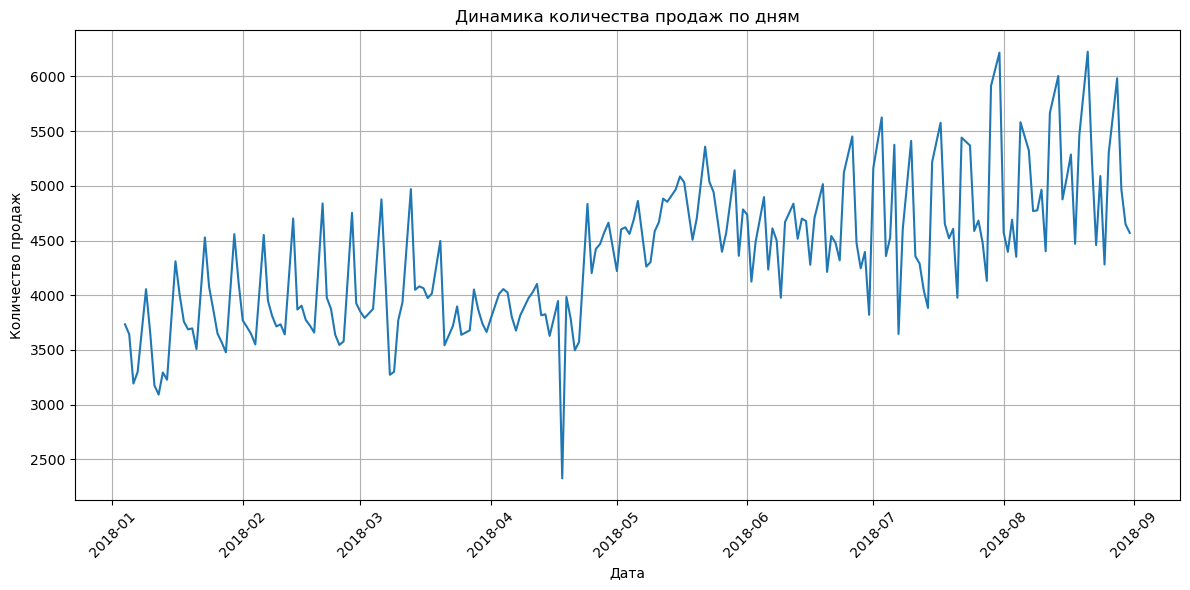

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(grouped_df['Date'], grouped_df['Number'])
plt.title('Динамика количества продаж по дням')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Строка с максимальным выбросом продаж

In [8]:
max_row = grouped_df.loc[grouped_df['Number'].idxmax()]
print('Строка с максимальным количеством продаж:')
max_row

Строка с максимальным количеством продаж:


Date      2018-08-21 00:00:00
Number                   6226
Name: 195, dtype: object

## 7. Топовый товар по продажам по средам за июнь, июль и август со склада 3

In [9]:
if 'Store' not in sales.columns or 'Product' not in sales.columns:
    print('В sales нет колонок Store и/или Product, поэтому этот пункт пропущен.')
else:
    sales['month'] = sales['Date'].dt.month
    sales['weekday'] = sales['Date'].dt.weekday  # среда = 2

    store_values = sales['Store'].astype(str).str.strip().str.lower()
    mask_store = store_values.isin(['store_3', 'store 3', '3', 'склад_3', 'склад 3'])

    filtered = sales[
        sales['month'].isin([6, 7, 8]) &
        (sales['weekday'] == 2) &
        mask_store
    ].copy()

    if filtered.empty:
        print('По заданному условию строки не найдены.')
    else:
        top_product = (
            filtered.groupby('Product', as_index=False)['Number']
                    .sum()
                    .sort_values('Number', ascending=False)
        )
        top_product.head(10)

## 8. Загрузка и подготовка погодных данных

In [10]:
df_weather = pd.read_excel('weather.xls')
print(df_weather.head())

df_weather['Дата'] = pd.to_datetime(df_weather['Дата'])

print('Размер weather_df:', df_weather.shape)

        Дата     T
0 2018-08-31   9.6
1 2018-08-31  11.3
2 2018-08-31  12.3
3 2018-08-31  13.2
4 2018-08-31  12.5
Размер weather_df: (1918, 2)


## 11. Объединение продаж и температуры

In [11]:
# приводим название даты к одному формату
grouped_df = grouped_df.rename(columns={'Date':'Дата'})

merged_df = pd.merge(grouped_df, df_weather, on='Дата')

print("Размер merged_df:", merged_df.shape)
merged_df.head()

Размер merged_df: (1639, 3)


,Дата,Number,T
0,2018-01-04,3734,-17.2
1,2018-01-04,3734,-14.5
2,2018-01-04,3734,-9.6
3,2018-01-04,3734,-12.3
4,2018-01-04,3734,-12.6


In [12]:
print(merged_df.columns)

Index(['Дата', 'Number', 'T'], dtype='object')


## 12. График зависимости количества продаж от температуры

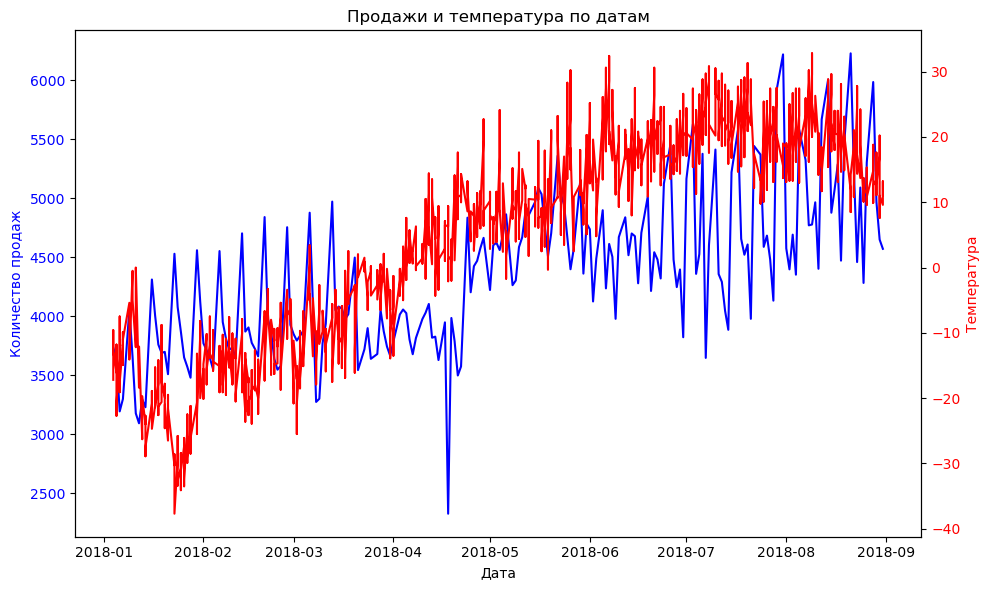

In [13]:
fig, ax1 = plt.subplots(figsize=(10,6))

ax1.plot(merged_df['Дата'], merged_df['Number'], color='blue')
ax1.set_xlabel('Дата')
ax1.set_ylabel('Количество продаж', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()

ax2.plot(merged_df['Дата'], merged_df['T'], color='red')
ax2.set_ylabel('Температура', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Продажи и температура по датам')

fig.tight_layout()
plt.show()

## 13. Отдельный график температуры

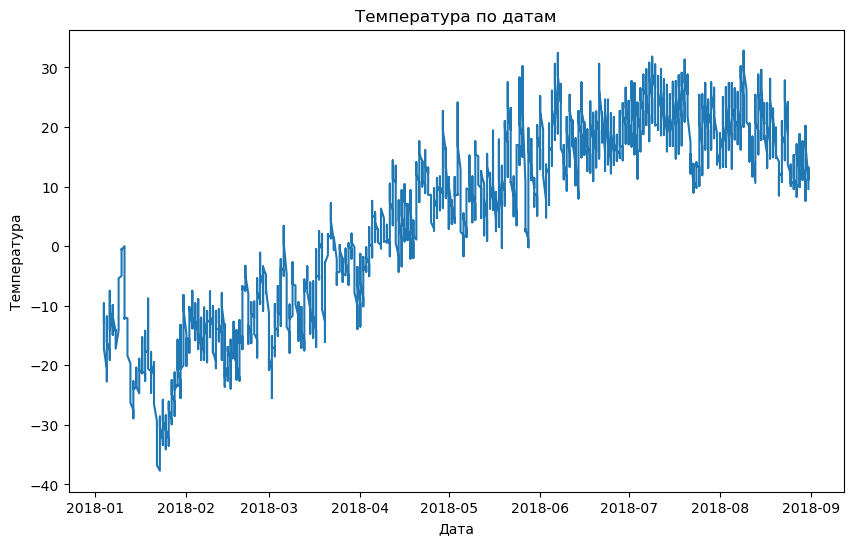

In [14]:
plt.figure(figsize=(10,6))

plt.plot(df_weather['Дата'], df_weather['T'])

plt.title('Температура по датам')
plt.xlabel('Дата')
plt.ylabel('Температура')

plt.show()

## 14. Итоговый вывод

В ходе работы был проведен анализ данных о продажах и погодных условиях.

В рамках анализа были выполнены следующие шаги:
- загружены и подготовлены данные о продажах;
- выполнена агрегация продаж по датам;
- определен товар с наибольшими продажами по заданным условиям;
- загружены данные о температуре воздуха;
- выполнено объединение датасетов продаж и погодных данных по дате;
- построены графики для визуального анализа зависимости продаж от температуры.

По результатам анализа можно сделать следующие выводы:

- наблюдается определенная зависимость между температурой воздуха и количеством продаж;
- в периоды повышения температуры количество продаж также имеет тенденцию к увеличению;
- однако зависимость не является строго линейной, что может быть связано с влиянием дополнительных факторов (сезонность, акции, спрос на отдельные товары и т.д.).

Таким образом, погодные условия могут оказывать влияние на динамику продаж, однако для более точного анализа требуется учитывать и другие факторы.